In [4]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoMultivariateNormal
from numpyro.optim import Adam


from core.datasetclass import TractionDataset
from core.utils import * 
from core.model import StrainGPModel, NHPrior, NHPriorFunc

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [175]:
@jax.vmap
def invariants_and_derivatives(F):
    f = fto3x3(F)
    C = f.T @ f
    I1 = jnp.trace(C)
    I2 = 0.5 * (I1**2 - jnp.trace(C @ C))
    I3 = jnp.linalg.det(C)
    # derivatives wrt F (2x2)
    dI1_dF = 2*f
    dI2_dF = 2*(I1*f - f @ C)
    dI3_dF = 2*jnp.linalg.det(f)**2 * jnp.linalg.inv(f).T
    dI_dF = jnp.stack([dI1_dF, dI2_dF, dI3_dF])  # (3,2,2)
    return jnp.array([I1, I2, I3]), dI_dF

In [306]:
import jax.numpy as jnp
import jax

@jax.jit
def rbf_kernel(X1: jnp.array, X2: jnp.array, variance: float, lengthscales: jnp.array) -> jnp.array:
    """
    Computes the ARD RBF Gram/Covariance matrix.
    X1, X2 are (N, D) and (M, D).
    lengthscales is a vector (D,).
    """
    # 1. Calculate the raw difference tensor: (N, M, D)
    diff = X1[:, None, :] - X2[None, :, :]
    
    # 2. Apply the weighted (inverse lengthscale squared) distance for each dimension
    # This is the core ARD step: (x_d - x'_d)^2 / (l_d)^2
    # The exponent is a sum over the D dimension: (N, M)
    exponent = jnp.sum((diff / lengthscales)**2, axis=-1)
    
    # RBF formula: k(x, x') = sigma^2 * exp(- 0.5 * sum_d (x_d - x'_d)^2 / (l_d)^2)
    K = variance * jnp.exp(-0.5 * exponent)
    return K

import jax.numpy as jnp
import jax

@jax.jit
def matern52_kernel(X1: jnp.array, X2: jnp.array, variance: float, lengthscales: jnp.array) -> jnp.array:
    """
    Computes the ARD Matern 5/2 Gram matrix.
    X1: (N, D), X2: (M, D), lengthscales: (D,)
    """
    # 1. Scaled squared difference: sum_d ( (x_d - x'_d) / l_d )^2
    # This represents the squared Mahalanobis distance
    diff = X1[:, None, :] - X2[None, :, :]
    dist_sq = jnp.sum((diff / lengthscales)**2, axis=-1)
    
    # 2. Add a small epsilon for numerical stability when taking the sqrt
    # dist = sqrt(sum (delta_x / l)^2)
    dist = jnp.sqrt(jnp.maximum(dist_sq, 1e-12))
    
    # 3. Matern 5/2 formula
    sqrt5 = jnp.sqrt(5.0)
    K = variance * (1.0 + sqrt5 * dist + (5.0/3.0) * dist_sq) * jnp.exp(-sqrt5 * dist)
    
    return K

In [638]:
def get_dev_invariants(I) :
    I1_dev = I[2]**(-1/3) * I[0]
    I2_dev = I[2]**(-2/3) * I[1]
    return jnp.stack([I1_dev, I2_dev, I[2]])

In [639]:
class PosteriorStrainEnergyFunction :
    def __init__(self, lengthscales, variance, smoothener, inducing_points, u_induced) :
        self.lengthscales = lengthscales 
        self.variance = variance
        self.smoothener = smoothener
        self.inducing_points = inducing_points
        self.u_induced = u_induced
    def __call__(self, i_star) :
        i_star = jnp.atleast_2d(i_star)
        i_star = jax.vmap(get_dev_invariants)(i_star)
        self.inducing_points = jax.vmap(get_dev_invariants)(self.inducing_points)
        Kzz = matern52_kernel(self.inducing_points, self.inducing_points, self.variance, self.lengthscales)
        # Kzz = rbf_kernel(self.inducing_points, self.inducing_points, self.variance, self.lengthscales)
        Kzz += 1e-6 * jnp.eye(self.inducing_points.shape[0])
        Kiz = matern52_kernel(i_star, self.inducing_points, self.variance, self.lengthscales)
        # Kiz = rbf_kernel(i_star, self.inducing_points, self.variance, self.lengthscales)
        weights = jnp.linalg.solve(Kzz, jnp.eye(self.inducing_points.shape[0])) @ (self.u_induced)
        # K0z = rbf_kernel(jnp.array([[3, 3, 1]]), self.inducing_points, self.variance, self.lengthscales)
        K0z = matern52_kernel(jnp.array([[3, 3, 1]]), self.inducing_points, self.variance, self.lengthscales)
        mu_star = Kiz @ weights
        mu_ref = K0z @ weights
        # return self.smoothener * (mu_star - mu_ref)**2 
        return (jnp.log(1 + jnp.exp(mu_star)) - jnp.log(1 + jnp.exp(mu_ref)))
    def _singular(self, i_star) :
        Psi_I = self.__call__(i_star).squeeze()
        return Psi_I

In [640]:
def _neumann_cell_force(coords_el, types_el, t3, t4):
    """
    coords_el: (3,2) float - coordinates of the 3 nodes of the element
    types_el:  (3,) int - node_type for these 3 nodes (global node_type[cells])
    t3, t4: scalars - traction magnitudes for types 3 and 4
    returns: (3,2) local nodal traction vector for this element
    """
    edges = jnp.array([[0, 1],
                       [1, 2],
                       [2, 0]])  # three local edges
    f_cell = jnp.zeros((3, 2))

    def body_fun(idx, f):
        i = edges[idx, 0]
        j = edges[idx, 1]

        ti = types_el[i]
        tj = types_el[j]

        # Only apply traction if both nodes of the edge have the same neumann type.
        is_right = (ti == 3) & (tj == 3)
        is_top   = (ti == 4) & (tj == 4)

        # choose traction vector for edge
        t_edge = jnp.where(is_right, jnp.array([t3, 0.0]),
                 jnp.where(is_top,   jnp.array([0.0, t4]),
                                         jnp.array([0.0, 0.0])))

        xi = coords_el[i]
        xj = coords_el[j]
        L = jnp.linalg.norm(xj - xi)

        # nodal contribution from this edge: each edge contributes L/2 * T to each of its two nodes
        fe_local = 0.5 * L * t_edge  # shape (2,)

        f = f.at[i].add(fe_local)
        f = f.at[j].add(fe_local)
        return f

    f_cell = jax.lax.fori_loop(0, 3, body_fun, f_cell)
    return f_cell  # (3,2)


def physical_loss(params, Z_I, coords, cells, u,
                  n_nodes, node_type):
    """
    params: (mu, kappa)
    coords: (C, 3, 2) per-element nodal coords
    cells:  (C, 3) global node indices per element
    u: displacement (format compatible with deformation_gradient_element)
    reaction_forces: target reaction vector (4,) or similar used previously
    n_nodes: total number of nodes
    bc: (n_nodes, 2) boundary code mask (0 free, 1..4 etc)
    node_type: (n_nodes, 1) ints: 0 free, 1/2 fixed (dirichlet), 3 right, 4 top
    load_parameter: (2,) or (2,1) - [t3, t4]
    """

    # --- INTERNAL FORCES (unchanged) ---
    F, dNdx = deformation_gradient_element(coords, u)   # (C,2,2), (C,3,2,2?) matches your API
    dA = jnp.linalg.det(transformation_jacobian(coords)) / 2  # (C,)
    # p_pos = jnp.exp(params)
    # strain_energy = strain_energy_func(f, p_pos)
    # piola = jax.grad(strain_energy_func)
    # piola = P_mr(f, p_pos)[:, :2, :2]   # (C,2,2)
    invariant_stacked, dI_dF_stacked = invariants_and_derivatives(F)
    strain_energy_func = PosteriorStrainEnergyFunction(params[:3], params[3], params[4], Z_I, params[5:]) 
    deriv_prior_mean = jax.vmap(jax.grad(strain_energy_func._singular))(invariant_stacked)
    piola = jnp.einsum("cnij, cn -> cij", dI_dF_stacked, deriv_prior_mean) [: ,:2, :2]

    # piola = piola_func(f)[:, :2, :2] 
    # internal element nodal forces: (C,3,2)
    f_int_cell = jnp.einsum("cij, cnj -> cin", piola, dNdx) * dA[:, None, None]
    f_int_cell = jnp.swapaxes(f_int_cell, 1, 2)    # (C,3,2)

    # assemble into global internal force vector (n_nodes, 2)
    f_int_nodes = jnp.zeros((n_nodes, 2)).at[cells].add(f_int_cell)
    
    # --- NEUMANN EDGE-LENGTH TRACTION ---
    # normalize load_parameter to flat array
    t3 = 0.5
    t4 = 0.5 * 1.01
    # node_type may be (n_nodes,1) so flatten
    node_type_flat = jnp.asarray(node_type).reshape(-1)  # (n_nodes,)
    types_per_cell = node_type_flat[cells]               # (C,3)

    # vectorize per-element traction computation
    per_cell_vmap = jax.vmap(_neumann_cell_force, in_axes=(0, 0, None, None))
    f_neu_cells = per_cell_vmap(coords, types_per_cell, t3, t4)  # (C,3,2)

    # assemble global neumann nodal forces
    f_neu_nodes = jnp.zeros((n_nodes, 2)).at[cells].add(f_neu_cells)

    # --- Residual R = int(grad v : P) dx  -  int(v·T) ds(Neumann)
    R_nodes = f_int_nodes - f_neu_nodes

    # only free DOFs contribute to the residual loss (bc == 0)
    blm_loss = jnp.sum(R_nodes[(node_type != 1) & (node_type != 2)] ** 2)

    fixed_nodes_loss1 = jnp.sum((jnp.sum(R_nodes[node_type == 1], axis = 0) + jnp.sum(f_neu_nodes[node_type == 3], axis = 0))**2)
    fixed_nodes_loss2 = jnp.sum((jnp.sum(R_nodes[node_type == 2], axis = 0) + jnp.sum(f_neu_nodes[node_type == 4], axis = 0))**2)
    Kzz = matern52_kernel(Z_I, Z_I, params[3], params[:3]) + 1e-6 * jnp.eye(50)
    reg_loss = (params[5:] @ jnp.linalg.solve(Kzz, params[5:])) * 1e-2
    return blm_loss + fixed_nodes_loss1 + fixed_nodes_loss2 + reg_loss, f_int_nodes, f_neu_nodes, R_nodes

In [641]:
dataset = TractionDataset("dataset","NH")
data = dataset[1]
coords = data["mesh_pos"][:,:2]
cells = data["cells"]
u = data["u"]
node_type = data["node_type"]
# load_parameter = data["load_parameter"]

coord_cells = coords[cells]
u_cells = u[cells]

F, dNdx = deformation_gradient_element(coord_cells, u_cells)
invariant_stacked, dI_dF_stacked = invariants_and_derivatives(F)

In [642]:
invariant_stacked.shape

(2224, 3)

In [643]:
inducing_points = 50

In [644]:
I_obs = invariant_stacked
Z_i1 = jnp.linspace(I_obs[:, 0].min(), I_obs[:, 0].max(), inducing_points)
Z_i2 = jnp.linspace(I_obs[:, 1].min(), I_obs[:, 1].max(), inducing_points)
Z_i3 = jnp.linspace(I_obs[:, 2].min(), I_obs[:, 2].max(), inducing_points)

Z_stacked = jnp.stack([Z_i1, Z_i2, Z_i3], axis = -1)

In [645]:
u_params = jnp.ones(inducing_points)
K_params = jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
params = jnp.concat([K_params, u_params]) 


In [646]:
import optax

# trainable parameters
u_params = jnp.ones(inducing_points)
K_params = jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
params = jnp.concat([K_params, u_params]) 


# choose optimizer
# opt = optax.lbfgs(1e-3)
opt = optax.adam(5e-2)
opt_state = opt.init(params)
n_nodes = int(cells.max()) + 1
# JIT the loss and gradients
loss_and_grad = jax.jit(jax.value_and_grad(
    lambda params: physical_loss(params, Z_stacked,coord_cells, cells, u_cells, coords.shape[0], node_type)[0]
))


for step in range(50000):
    loss, grads = loss_and_grad(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    if step % 50 == 0:
        print(f"step {step:04d}  loss={loss:.6f}")

step 0000  loss=3.537423
step 0050  loss=0.876423
step 0100  loss=0.454312
step 0150  loss=0.189462
step 0200  loss=0.087096
step 0250  loss=0.097704
step 0300  loss=0.050177
step 0350  loss=0.088244
step 0400  loss=0.044715
step 0450  loss=0.222863
step 0500  loss=0.051248
step 0550  loss=0.036046
step 0600  loss=0.336023
step 0650  loss=0.051653
step 0700  loss=0.034080
step 0750  loss=0.029101
step 0800  loss=0.139593
step 0850  loss=0.042723
step 0900  loss=0.030551
step 0950  loss=0.026510
step 1000  loss=0.129492
step 1050  loss=0.048924
step 1100  loss=0.029807
step 1150  loss=0.025419
step 1200  loss=0.023036
step 1250  loss=0.021418
step 1300  loss=0.082579
step 1350  loss=0.029672
step 1400  loss=0.024259
step 1450  loss=0.021716
step 1500  loss=0.020077
step 1550  loss=0.018880
step 1600  loss=0.181586
step 1650  loss=0.038591
step 1700  loss=0.024984
step 1750  loss=0.021442
step 1800  loss=0.019559
step 1850  loss=0.018282
step 1900  loss=0.017310
step 1950  loss=0.016522


KeyboardInterrupt: 

In [647]:
strain_energy_func = PosteriorStrainEnergyFunction(params[:3], params[3], params[4], Z_stacked, params[5:])

In [648]:
loss

Array(0.00537302, dtype=float64)

In [649]:
params

Array([ 7.87873790e-01,  3.90526864e+01,  8.69964545e-01,  3.54692072e+02,
        1.00000000e+00, -1.15890641e+00, -1.02176257e+00, -9.56022871e-01,
       -8.59382298e-01, -8.02379710e-01, -7.38000879e-01, -6.78425721e-01,
       -6.17268945e-01, -5.77333497e-01, -5.37610878e-01, -5.08559221e-01,
       -4.73690049e-01, -4.49573423e-01, -4.20470366e-01, -3.98669824e-01,
       -3.84071413e-01, -3.70587293e-01, -3.55952373e-01, -3.37443587e-01,
       -3.15871078e-01, -3.01705921e-01, -2.99675559e-01, -2.97092637e-01,
       -2.81367921e-01, -2.64797006e-01, -2.58171454e-01, -2.55093986e-01,
       -2.52826871e-01, -2.38696258e-01, -2.39679520e-01, -2.59718561e-01,
       -2.66958270e-01, -2.70953760e-01, -2.82723301e-01, -2.85887420e-01,
       -2.81078428e-01, -2.87613229e-01, -3.09467449e-01, -3.32334427e-01,
       -3.45245905e-01, -3.43904269e-01, -3.48661248e-01, -3.43394421e-01,
       -3.06836648e-01, -2.58571482e-01, -2.19943394e-01, -1.98641500e-01,
       -1.96544345e-01, -

In [574]:
I_obs


Array([[3.83856261, 4.80881172, 1.97024911],
       [3.84174423, 4.81578001, 1.97403578],
       [3.84419219, 4.82192758, 1.97773539],
       ...,
       [3.82042136, 4.79705207, 1.97663071],
       [3.8185021 , 4.79234289, 1.97384079],
       [3.81549876, 4.78543563, 1.96993687]], dtype=float64)

In [650]:
psi_pred = strain_energy_func(I_obs)

In [651]:
strain_energy_func(jnp.array([3,3,1]))

Array([0.], dtype=float64)

In [619]:
psi_pred

Array([0.06412664, 0.06442891, 0.06418552, ..., 0.07392354, 0.07081259,
       0.07273367], dtype=float64)

In [536]:
params[:3], params[3], Z_stacked, params[4:]

(Array([0.90525354, 4.65300305, 4.37335812], dtype=float64),
 Array(-0.86293903, dtype=float64),
 Array([[ 3.79918507,  4.75581286,  1.33461047],
        [ 4.12171396,  5.12585857,  1.39758456],
        [ 4.44424285,  5.49590427,  1.46055865],
        [ 4.76677174,  5.86594998,  1.52353274],
        [ 5.08930063,  6.23599568,  1.58650683],
        [ 5.41182953,  6.60604139,  1.64948092],
        [ 5.73435842,  6.97608709,  1.71245501],
        [ 6.05688731,  7.3461328 ,  1.7754291 ],
        [ 6.3794162 ,  7.7161785 ,  1.8384032 ],
        [ 6.70194509,  8.08622421,  1.90137729],
        [ 7.02447398,  8.45626991,  1.96435138],
        [ 7.34700287,  8.82631562,  2.02732547],
        [ 7.66953176,  9.19636132,  2.09029956],
        [ 7.99206065,  9.56640703,  2.15327365],
        [ 8.31458954,  9.93645274,  2.21624774],
        [ 8.63711843, 10.30649844,  2.27922183],
        [ 8.95964732, 10.67654415,  2.34219592],
        [ 9.28217621, 11.04658985,  2.40517001],
        [ 9.60470511,

In [537]:
Kss = rbf_kernel(I_obs, I_obs, params[3], params[:3])

In [288]:
Ksz = rbf_kernel(I_obs, Z_stacked, params[3], params[:3])
Kzz = rbf_kernel(Z_stacked, Z_stacked, params[3], params[:3])

In [289]:
Kzs = rbf_kernel(Z_stacked, I_obs, params[3], params[:3])

In [290]:
Kss - Ksz @ jnp.linalg.inv(Kzz) @ Kzs

Array([[ 88.29007156,  88.27059703,  88.24907019, ...,  87.49519907,
         87.54318911,  87.64065272],
       [131.08080332, 131.12913973, 131.19110142, ..., 133.68565292,
        133.62446919, 133.45391524],
       [ 53.92637885,  53.90636907,  53.88318673, ...,  53.034678  ,
         53.07644438,  53.1670033 ],
       ...,
       [ 86.15054396,  86.14849947,  86.14805115, ...,  86.19670533,
         86.21442704,  86.24062751],
       [108.85214773, 108.86863626, 108.89136917, ..., 109.88059127,
        109.86872245, 109.8200032 ],
       [102.40784078, 102.4410128 , 102.48377698, ..., 104.2215074 ,
        104.18045974, 104.06395423]], dtype=float64)

In [538]:
deriv_prior_mean = jax.vmap(jax.grad(strain_energy_func._singular))(invariant_stacked)
piola = jnp.einsum("cnij, cn -> cij", dI_dF_stacked, deriv_prior_mean)

In [539]:
piola

Array([[[ 1.51334206e+00, -2.04975440e-03,  0.00000000e+00],
        [-1.50310820e-03,  1.72118705e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.39173140e+00]],

       [[ 1.52129911e+00, -2.27765114e-03,  0.00000000e+00],
        [ 1.65693757e-04,  1.73201279e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.39902283e+00]],

       [[ 1.52843145e+00, -4.67559861e-03,  0.00000000e+00],
        [-2.05076167e-03,  1.73937886e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.40456511e+00]],

       ...,

       [[ 1.61863052e+00, -1.83016846e-03,  0.00000000e+00],
        [-3.90114035e-03,  1.51376050e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.34947087e+00]],

       [[ 1.61263104e+00,  1.44942850e-04,  0.00000000e+00],
        [-1.91678978e-03,  1.50762431e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.34474223e+00]],

       [[ 1.60211974e+00, -1.34973253e-03,  0.00000000e+00],
 

In [224]:
piola

Array([[[ 1.28824118e+00, -6.30282075e-04,  0.00000000e+00],
        [-1.51787702e-03,  1.44425727e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.23192938e+00]],

       [[ 1.29054550e+00,  3.47049078e-04,  0.00000000e+00],
        [-1.77499800e-03,  1.44580346e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.23347071e+00]],

       [[ 1.29238386e+00, -6.52431774e-04,  0.00000000e+00],
        [-3.44212753e-03,  1.44825184e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.23515668e+00]],

       ...,

       [[ 1.26860505e+00, -8.72225708e-03,  0.00000000e+00],
        [-1.74304741e-03,  1.56331101e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.26598110e+00]],

       [[ 1.26567499e+00, -4.19925764e-03,  0.00000000e+00],
        [ 8.19814203e-04,  1.56197644e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.26435611e+00]],

       [[ 1.26257757e+00, -3.81337198e-03,  0.00000000e+00],
 

In [652]:
from core.material_models import get_material

In [653]:
Psi_true =get_material("neohookean")

In [654]:
f = jax.vmap(fto3x3)(F)

In [655]:
psi_true = Psi_true.phi(f)

In [656]:
psi_true

Array([0.03625934, 0.03652532, 0.03632866, ..., 0.04640709, 0.04320139,
       0.04519898], dtype=float64)

In [657]:
psi_pred = strain_energy_func(I_obs)


In [658]:
psi_pred

Array([0.15256302, 0.15295246, 0.15267262, ..., 0.16750554, 0.16294691,
       0.16581777], dtype=float64)

In [404]:
import matplotlib as mpl
import matplotlib.pyplot as plt

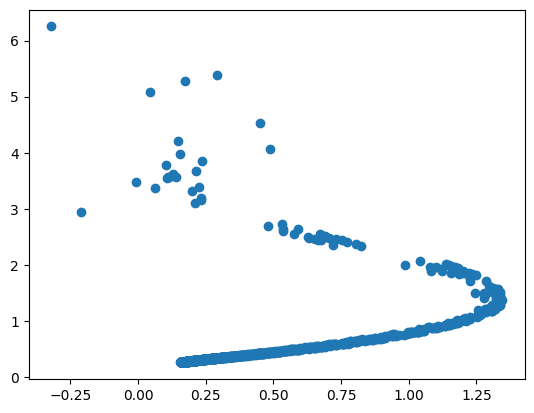

In [405]:
plt.scatter(psi_pred, psi_true)

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1961/2009128357.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('True $\psi$')
/tmp/ipykernel_1961/2009128357.py:24: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Predicted $\psi$')


R2 score: 0.3838029427551102


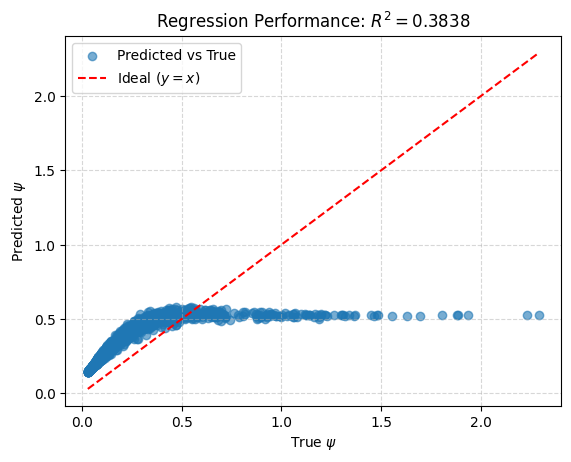

In [659]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

# Generating synthetic data to simulate psi_true and psi_pred
np.random.seed(42)
# Adding some noise to simulate predictions

# Calculate R2
filter = psi_true >= 0 
r2 = r2_score(psi_true[filter], psi_pred[filter])

# Create the plot
plt.scatter(psi_true[filter], psi_pred[filter], alpha=0.6, label='Predicted vs True')

# Isoline (y = x)
min_val = min(psi_true.min(), psi_pred.min())
max_val = max(psi_true.max(), psi_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal ($y=x$)')

# Formatting
plt.xlabel('True $\psi$')
plt.ylabel('Predicted $\psi$')
plt.title(f'Regression Performance: $R^2 = {r2:.4f}$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Save image
plt.savefig('psi_regression_plot.png')

# Save data to CSV
df = pd.DataFrame({'psi_true': psi_true, 'psi_pred': psi_pred})
df.to_csv('psi_data.csv', index=False)

print(f"R2 score: {r2}")

In [670]:
gamma = jnp.linspace(0.01, 1.5, 100)

f_ut = jnp.zeros((100, 3, 3))
f_ut = f_ut.at[:,0,0].add(gamma)
f_ut = f_ut.at[:,1,1].add(1)
f_ut = f_ut.at[:,2,2].add(1)

In [671]:
invs_ut = invariants_and_derivatives(f_ut)[0]

In [672]:
psi_pred_ut = strain_energy_func(invs_ut) 

In [673]:
psi_true = Psi_true.phi(f_ut)
psi_true

Array([2.15155741e+01, 1.16097998e+01, 8.42448827e+00, 6.75139391e+00,
       5.68751640e+00, 4.93642601e+00, 4.36971922e+00, 3.92197834e+00,
       3.55607359e+00, 3.24923155e+00, 2.98664177e+00, 2.75822028e+00,
       2.55684280e+00, 2.37732057e+00, 2.21577701e+00, 2.06925232e+00,
       1.93544414e+00, 1.81253214e+00, 1.69905644e+00, 1.59383131e+00,
       1.49588281e+00, 1.40440278e+00, 1.31871453e+00, 1.23824668e+00,
       1.16251315e+00, 1.09109757e+00, 1.02364098e+00, 9.59832115e-01,
       8.99399616e-01, 8.42105703e-01, 7.87741056e-01, 7.36120599e-01,
       6.87080033e-01, 6.40472937e-01, 5.96168361e-01, 5.54048795e-01,
       5.14008451e-01, 4.75951812e-01, 4.39792389e-01, 4.05451656e-01,
       3.72858135e-01, 3.41946608e-01, 3.12657429e-01, 2.84935932e-01,
       2.58731907e-01, 2.33999145e-01, 2.10695040e-01, 1.88780235e-01,
       1.68218313e-01, 1.48975516e-01, 1.31020507e-01, 1.14324146e-01,
       9.88593004e-02, 8.46006663e-02, 7.15246164e-02, 5.96090581e-02,
      

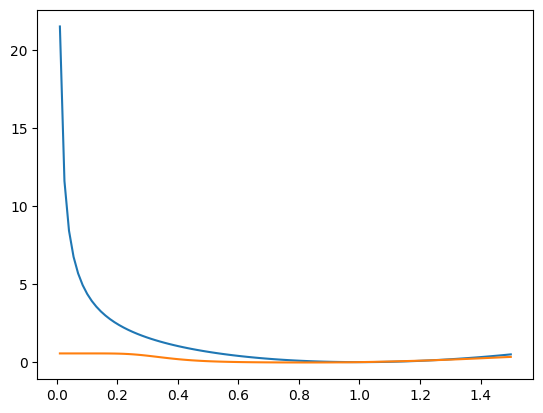

In [674]:
plt.plot(gamma, psi_true)
plt.plot(gamma, psi_pred_ut)

In [104]:
strain_energy_func = PosteriorStrainEnergyFunction(params[:3], params[3], Z_stacked, jnp.exp(params[4:]))
deriv_prior_mean = jax.vmap(jax.grad(strain_energy_func._singular))(invariant_stacked)

In [31]:
def model(u_obs, Z_I, beta=1e-4):
    M = Z_I.shape[0]

    # Kernel hyperparameters (MAP)
    lengthscales = numpyro.param(
        "lengthscales", jnp.array([1.0, 1.0, 1.0]), constraint=dist.constraints.positive
    )
    variance = numpyro.param(
        "variance", 1.0, constraint=dist.constraints.positive
    )
    nh_mean_func = jax.vmap(NHPriorFunc(mu = 1.0, kappa = 3.0))
    u_ = nh_mean_func(Z_I)
    post_psi_func = PosteriorStrainEnergyFunction(lengthscales, variance, Z_I, u_)



    # GP prior
    Kzz = rbf_kernel(Z_I, Z_I, variance, lengthscales)
    Kzz += 1e-6 * jnp.eye(M)
    # initial_u = nh_prior_mean(Z_I)
    u = numpyro.sample(
        "u",
        dist.MultivariateNormal(u_, Kzz)
    ) # define as nh, mr prior


    # Physics residual
    r = physical_loss(post_psi_func, coord_cells, cells, u_cells,
                  coords.shape[0], node_type)[0]   # <-- deterministic functional (VFM)

    # Energy-based likelihood
    numpyro.factor("physics", -beta * r)


In [32]:
def guide(u_obs, Z_I, beta=1.0):
    M = Z_I.shape[0]
    nh_mean_func = jax.vmap(NHPriorFunc(mu = 1.0, kappa = 3.0))
    u = nh_mean_func(Z_I)
    m = numpyro.param("u_loc", u)
    L = numpyro.param(
        "u_scale_tril",
        jnp.eye(M),
        constraint=dist.constraints.lower_cholesky
    )

    numpyro.sample(
        "u",
        dist.MultivariateNormal(m, scale_tril=L)
    )


In [40]:
optimizer = Adam(1e-3)
svi = SVI(model, guide, optimizer, Trace_ELBO())

svi_state = svi.init(
    jax.random.PRNGKey(0),
    u, I_obs, Z_stacked
)

for step in range(200):
    svi_state, loss = svi.update(
        svi_state, u, I_obs, Z_stacked
    )
    if step % 1 == 0:
        print(f"step {step}, loss = {loss:.2f}")


: 

In [34]:
params = svi.get_params(svi_state)

In [35]:
params

{'lengthscales': Array([0.98546741, 0.98625684, 0.98521519], dtype=float64),
 'u_loc': Array([0.23516735, 0.23378891, 0.23752198, 0.23710392, 0.22899624,
        0.22919739, 0.22866976, 0.2308587 , 0.22975862, 0.23642928,
        0.23900001, 0.23262131, 0.24114296, 0.24090815, 0.23327622,
        0.24511599, 0.23173306, 0.23905857, 0.23619761, 0.22612617,
        0.24140245, 0.25180253, 0.23886427, 0.24619509, 0.24300637,
        0.23473164, 0.23261494, 0.23731193, 0.24136139, 0.23476635,
        0.23916587, 0.2296536 , 0.23752471, 0.22854574, 0.23046964,
        0.23470725, 0.24011992, 0.23895707, 0.23906714, 0.23245834,
        0.24048064, 0.23454327, 0.23974589, 0.23489292, 0.23016839,
        0.22319513, 0.24105824, 0.2380006 , 0.23303906, 0.23881291,
        0.22734167, 0.23626589, 0.23828393, 0.23241466, 0.22513894,
        0.23234658, 0.21706927, 0.252561  , 0.22891745, 0.2396669 ,
        0.24089852, 0.23160425, 0.23767425, 0.23742899, 0.23101355,
        0.22971591, 0.2167828 

In [36]:
post_psi_func = PosteriorStrainEnergyFunction(params["lengthscales"], params["variance"], Z_stacked, params["u_loc"])

In [37]:
svi.get_params(svi_state).keys()

dict_keys(['lengthscales', 'u_loc', 'u_scale_tril', 'variance'])

In [38]:
physical_loss(post_psi_func, coord_cells, cells, u_cells,
                  coords.shape[0], node_type)[0]

Array(4.99056222, dtype=float64)

In [16]:
I_obs = invariant_stacked

In [26]:
Z_i1 = jnp.linspace(I_obs[:, 0].min(), I_obs[:, 0].max(), 50)
Z_i2 = jnp.linspace(I_obs[:, 1].min(), I_obs[:, 1].max(), 50)
Z_i3 = jnp.linspace(I_obs[:, 2].min(), I_obs[:, 2].max(), 50)

Z_stacked = jnp.stack([Z_i1, Z_i2, Z_i3], axis = -1)


In [28]:
Z_stacked

Array([[ 3.72301898,  4.55951148,  1.25144988],
       [ 3.93897578,  4.81258784,  1.30050907],
       [ 4.15493258,  5.06566419,  1.34956827],
       [ 4.37088938,  5.31874054,  1.39862747],
       [ 4.58684619,  5.5718169 ,  1.44768667],
       [ 4.80280299,  5.82489325,  1.49674586],
       [ 5.01875979,  6.07796961,  1.54580506],
       [ 5.23471659,  6.33104596,  1.59486426],
       [ 5.45067339,  6.58412231,  1.64392346],
       [ 5.66663019,  6.83719867,  1.69298265],
       [ 5.882587  ,  7.09027502,  1.74204185],
       [ 6.0985438 ,  7.34335137,  1.79110105],
       [ 6.3145006 ,  7.59642773,  1.84016025],
       [ 6.5304574 ,  7.84950408,  1.88921944],
       [ 6.7464142 ,  8.10258044,  1.93827864],
       [ 6.96237101,  8.35565679,  1.98733784],
       [ 7.17832781,  8.60873314,  2.03639704],
       [ 7.39428461,  8.8618095 ,  2.08545624],
       [ 7.61024141,  9.11488585,  2.13451543],
       [ 7.82619821,  9.36796221,  2.18357463],
       [ 8.04215501,  9.62103856,  2.232

In [30]:
Kzz = rbf_kernel(Z_stacked, Z_stacked, 1.0, jnp.array([1.0, 1.0, 1.0]))
Kzz += 1e-6 * jnp.eye(50)

In [74]:
u = jnp.zeros(50)

In [ ]:
nh_mean_func = jax.vmap(NHPriorFunc(mu = 0.5, kappa = 1.0))

In [68]:
u = nh_mean_func(Z_stacked)

In [75]:
u.max()

Array(0., dtype=float64)

In [ ]:
class PosteriorStrainEnergyFunction :
    def __init__(self, lengthscales, variance, inducing_points, u_induced) :
        self.lengthscales = lengthscales 
        self.variance = variance
        self.inducing_points = inducing_points
        self.u_induced = u_induced
    def __call__(self, i_star) :
        if len(i_star.shape) != 2 :
            i_star = i_star[None, :]
        Kzz = rbf_kernel(self.inducing_points, self.inducing_points, self.variance, self.lengthscales)
        Kzz += 1e-6 * jnp.eye(self.inducing_points.shape[0])
        Kiz = rbf_kernel(i_star, self.inducing_points, self.variance, self.lengthscales)
        Kzz_inv = jnp.linalg.solve(Kzz, jnp.eye(self.inducing_points.shape[0]))
        Psi_I = Kiz @ Kzz_inv @ self.u_induced
        return Psi_I[0]

In [ ]:
post_psi_func = PosteriorStrainEnergyFunction(jnp.array([1.0, 1.0, 1.0]), 1.0, Z_stacked, u)




In [78]:
jax.vmap(jax.grad(post_psi_func))(I_obs)

Array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float64)

In [79]:
physical_loss(post_psi_func, coord_cells, cells, u_cells,
                  coords.shape[0], node_type)[0]

Array(3.74797637, dtype=float64)

In [ ]:
import numpy as np
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, VBox

def kl_divergence(m1, s1, m2, s2):
    # Standard KL Divergence formula for two univariate Gaussians
    return np.log(s2/s1) + (s1**2 + (m1 - m2)**2) / (2 * s2**2) - 0.5

# Setup the initial x-axis range
x = np.linspace(-10, 10, 1000)

def update_plot(m1=0.0, s1=1.0, m2=2.0, s2=1.0):
    # Calculate PDFs
    y1 = (1 / (s1 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m1) / s1)**2)
    y2 = (1 / (s2 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m2) / s2)**2)
    
    kl_val = kl_divergence(m1, s1, m2, s2)
    
    # Create the figure
    fig = go.Figure()
    
    # Add Distribution 1
    fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='P (Dist 1)', fill='tozeroy'))
    
    # Add Distribution 2
    fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='Q (Dist 2)', fill='tozeroy'))
    
    # Update layout with KL Divergence text
    fig.update_layout(
        title=f"KL Divergence D(P||Q): {kl_val:.4f}",
        xaxis_title="Value",
        yaxis_title="Density",
        yaxis=dict(range=[0, 1]),
        template="plotly_white",
        annotations=[
            dict(
                x=0, y=0.9, xref="paper", yref="paper",
                text=f"Mean 1: {m1} | Std 1: {s1}<br>Mean 2: {m2} | Std 2: {s2}",
                showarrow=False, font=dict(size=12)
            )
        ]
    )
    fig.show()

# Create sliders
interact(
    update_plot,
    m1=FloatSlider(value=0, min=-5, max=5, step=0.1, description='Mean P'),
    s1=FloatSlider(value=1, min=0.1, max=3, step=0.1, description='Std P'),
    m2=FloatSlider(value=2, min=-5, max=5, step=0.1, description='Mean Q'),
    s2=FloatSlider(value=1, min=0.1, max=3, step=0.1, description='Std Q')
)